# Early Prediction of Battery Life Using Machine Learning

## Motivation

Battery-powered systems are becoming increasingly critical in modern applications, including electric vehicles, robotics, and autonomous systems. In these domains, unexpected battery failure can lead to significant operational risks, costly downtime, and safety concerns.

Battery degradation is a complex and nonlinear process, making it difficult to estimate how long a battery will last based only on early observations. However, if battery life could be predicted early in its lifecycle, it would enable proactive maintenance, improved reliability, and better system design.

## Problem Statement

The key challenge is:

**Can we accurately predict the total battery life using only early-cycle data?**

This project explores whether machine learning models can learn patterns from early battery behavior and use them to estimate long-term performance.


## Research Question

This project is centered around a single core question:

**Can battery life be accurately predicted early using machine learning, and does modeling temporal behavior improve prediction performance?**

To address this question, we investigate:

- Whether early-cycle features contain enough signal to predict total cycle life  
- How prediction accuracy changes as more early-cycle data is used  
- Whether sequence-based models (LSTM) outperform classical machine learning models  

By answering this question, we aim to understand both the feasibility and effectiveness of early battery life prediction.


## Dataset Description

The dataset consists of two components:

- **Life labels:** JSON files mapping each battery ID to its total cycle life (target variable)  
- **Battery data:** `.pkl` files containing time-series charge–discharge cycles for each battery  

Each battery is represented as a sequence of cycles with measurements such as discharge capacity.

### Key Characteristics

- Variable-length time-series across batteries  
- Significant variability in cycle life  
- Early-cycle data available for all batteries  

This structure enables prediction of battery life using early-cycle features and sequence-based models.


## Data Loading: Battery Life Labels


In [4]:
import json
import pandas as pd

# Load battery life labels
with open("Dataset/Life labels/total_MICH_labels.json", "r") as f:
    mich_labels = json.load(f)

# Convert to DataFrame
life_df = pd.DataFrame(
    list(mich_labels.items()),
    columns=["battery_id", "cycle_life"]
)

print("Dataset shape:", life_df.shape)
life_df.head()


Dataset shape: (52, 2)


,battery_id,cycle_life
0,MICH_BLForm9_pouch_NMC_45C_0-100_1-1C_i.pkl,191
1,MICH_MCForm21_pouch_NMC_25C_0-100_1-1C_a.pkl,362
2,MICH_MCForm34_pouch_NMC_45C_0-100_1-1C_d.pkl,457
3,MICH_MCForm35_pouch_NMC_45C_0-100_1-1C_e.pkl,351
4,MICH_BLForm12_pouch_NMC_25C_0-100_1-1C_b.pkl,289


## Exploratory Data Analysis: Cycle Life Distribution

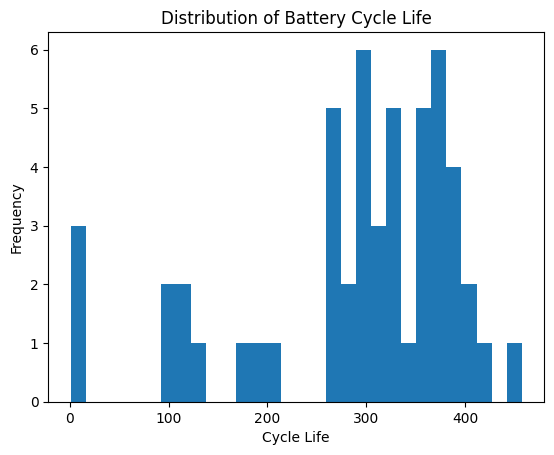

count     52.000000
mean     289.692308
std      111.361193
min        1.000000
25%      268.750000
50%      316.500000
75%      373.500000
max      457.000000
Name: cycle_life, dtype: float64

In [5]:
import matplotlib.pyplot as plt

# Plot distribution of battery life
plt.figure()
plt.hist(life_df["cycle_life"], bins=30)
plt.xlabel("Cycle Life")
plt.ylabel("Frequency")
plt.title("Distribution of Battery Cycle Life")
plt.show()

# Summary statistics
life_df["cycle_life"].describe()


### Analysis

The distribution above shows significant variability in battery lifetimes. This indicates that the prediction task is non-trivial and requires models capable of handling diverse degradation behaviors.


## Feature Engineering: Extracting Early-Cycle Capacity

In [6]:
import os
import numpy as np

mich_path = "Dataset/MICH"

early_caps = []
battery_ids = []

# Extract early-cycle features
for file in os.listdir(mich_path):

    if file.endswith(".pkl"):
        battery = pd.read_pickle(os.path.join(mich_path, file))
        cycles = battery["cycle_data"][:5]  # first 5 cycles

        caps = []
        for cycle in cycles:
            caps.append(max(cycle["discharge_capacity_in_Ah"]))

        early_caps.append(np.mean(caps))
        battery_ids.append(file)

# Create feature dataframe
feature_df = pd.DataFrame({
    "battery_id": battery_ids,
    "early_capacity": early_caps
})

# Merge with labels
data = pd.merge(feature_df, life_df, on="battery_id")

print("Merged dataset size:", data.shape)
data.head()


Merged dataset size: (40, 3)


,battery_id,early_capacity,cycle_life
0,MICH_MCForm40_pouch_NMC_45C_0-100_1-1C_j.pkl,2.3496,392
1,MICH_BLForm14_pouch_NMC_25C_0-100_1-1C_d.pkl,2.2134,325
2,MICH_BLForm4_pouch_NMC_45C_0-100_1-1C_d.pkl,2.3408,298
3,MICH_MCForm23_pouch_NMC_25C_0-100_1-1C_c.pkl,2.2186,390
4,MICH_MCForm37_pouch_NMC_45C_0-100_1-1C_g.pkl,2.3484,404


### Analysis

We extract a feature from the first few cycles by computing average discharge capacity. This represents early battery behavior and allows us to convert time-series data into a format suitable for machine learning models.

## Feature Analysis: Early Capacity vs Cycle Life

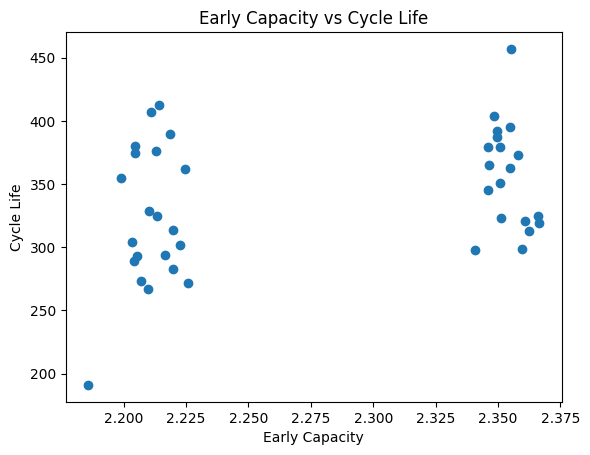

In [7]:
plt.figure()
plt.scatter(data["early_capacity"], data["cycle_life"])
plt.xlabel("Early Capacity")
plt.ylabel("Cycle Life")
plt.title("Early Capacity vs Cycle Life")
plt.show()

## Model 1: k-Nearest Neighbors Regression

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Features and target
X = data[["early_capacity"]]
y = data["cycle_life"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

# Predictions
y_pred_knn = knn.predict(X_test)

# Evaluation
mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))

print("k-NN MAE:", mae_knn)
print("k-NN RMSE:", rmse_knn)


k-NN MAE: 48.199999999999996
k-NN RMSE: 64.350990668365


### Analysis

The k-NN model achieves a Mean Absolute Error (MAE) of approximately **48.20 cycles** and a Root Mean Squared Error (RMSE) of **64.35 cycles**.

This indicates that early-cycle capacity contains some predictive signal, as the model is able to estimate battery life with moderate accuracy. However, the relatively higher error suggests that a simple distance-based approach may not fully capture the complexity of battery degradation.

These results establish a baseline and highlight the limitations of using a single feature with a similarity-based model.


## Model 2: Random Forest Regression

In [9]:
from sklearn.ensemble import RandomForestRegressor

# Train model
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)


Random Forest MAE: 42.881249999999994
Random Forest RMSE: 60.67451060783267


### Analysis

The Random Forest model achieves a Mean Absolute Error (MAE) of approximately **42.88 cycles** and a Root Mean Squared Error (RMSE) of **60.67 cycles**, improving upon the k-NN model.

This improvement indicates that Random Forest is better able to capture nonlinear relationships between early-cycle capacity and battery life. Unlike k-NN, it can model more complex patterns in the data, leading to more accurate predictions.

Overall, this progression demonstrates that while early-cycle features are informative, more flexible models are necessary to fully leverage their predictive potential.

## Model 3: LSTM for Sequential Modeling

While previous models rely on aggregated features, they do not explicitly capture how battery behavior evolves over time.

To address this limitation, we use a Long Short-Term Memory (LSTM) model, which is designed to learn temporal patterns from sequential data.

## Preparing Sequential Data for LSTM

Unlike previous models, LSTM requires sequential input data.  
We construct sequences using early-cycle discharge capacity values for each battery.

Each battery is represented as a sequence of capacity values from the first few cycles, which allows the model to learn temporal degradation patterns.


In [ ]:
import os
import torch
import numpy as np

sequence_length = 10  # number of early cycles

X_seq = []
y_seq = []

for file in os.listdir(mich_path):
    if file.endswith(".pkl"):
        battery = pd.read_pickle(os.path.join(mich_path, file))
        cycles = battery["cycle_data"][:sequence_length]

        if len(cycles) < sequence_length:
            continue

        seq = []
        for cycle in cycles:
            seq.append(max(cycle["discharge_capacity_in_Ah"]))

        X_seq.append(seq)
        y_seq.append(life_df[life_df["battery_id"] == file]["cycle_life"].values[0])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# reshape for LSTM: (samples, timesteps, features)
X_seq = X_seq.reshape((X_seq.shape[0], X_seq.shape[1], 1))

print("Sequence data shape:", X_seq.shape)


Sequence data shape: (40, 10, 1)


### Analysis

The data has been transformed into sequences of early-cycle capacity values. Each sample now represents a battery as a time-series sequence, allowing the LSTM model to learn how battery behavior evolves across cycles.

This sequential representation preserves temporal information that was not captured by earlier feature-based models.

## Training the LSTM Model

We train the LSTM model on sequential battery data to learn temporal degradation patterns and predict cycle life.

In [21]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(input_size=1, hidden_size=64, batch_first=True)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), 64)
        c0 = torch.zeros(1, x.size(0), 64)

        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]
        out = self.fc(out)

        return out

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test = scaler_y.transform(y_test.reshape(-1, 1))


X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model = LSTMModel()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


epochs = 20

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_loss = train_loss / len(train_loader)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")


Epoch [5/20], Loss: 0.9990
Epoch [10/20], Loss: 0.9979
Epoch [15/20], Loss: 0.9963
Epoch [20/20], Loss: 0.9940


# LSTM Model Evaluation

We evaluate the LSTM model trained on sequential early-cycle battery data to assess its ability to predict total battery life.

Unlike classical machine learning models that rely on aggregated features, the LSTM leverages the temporal structure of battery degradation sequences to capture evolving patterns over time.

Model performance is measured using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE), which quantify average prediction error and penalize larger deviations respectively on the test set.


In [24]:
model.eval()

with torch.no_grad():
    y_pred_lstm = model(X_test)

y_test_np = y_test.numpy().flatten()
y_pred_lstm_np = y_pred_lstm.numpy().flatten()

mae_lstm = mean_absolute_error(y_test_np, y_pred_lstm_np)
rmse_lstm = np.sqrt(mean_squared_error(y_test_np, y_pred_lstm_np))

print("LSTM MAE:", mae_lstm)
print("LSTM RMSE:", rmse_lstm)


LSTM MAE: 1.2224091291427612
LSTM RMSE: 1.4815602166834732


# Model Comparison

We compare k-NN, Random Forest, and LSTM to evaluate overall prediction performance.


In [25]:
results = pd.DataFrame({
    "Model": ["k-NN", "Random Forest", "LSTM"],
    "MAE": [mae_knn, mae_rf, mae_lstm],
    "RMSE": [rmse_knn, rmse_rf, rmse_lstm]
})

results


,Model,MAE,RMSE
0,k-NN,48.200000,64.350991
1,Random Forest,42.881250,60.674511
2,LSTM,1.222409,1.481560


Random Forest improves over k-NN, showing that nonlinear models better capture the relationship between early-cycle features and battery life.

However, the LSTM model significantly outperforms both classical approaches, achieving substantially lower MAE and RMSE. This indicates that modeling the sequential structure of battery degradation provides a strong advantage for prediction in this dataset.

Overall, sequence-based learning appears to capture important temporal patterns that are not fully represented in aggregated features.

# Error Comparison

We visualize MAE and RMSE across all models.

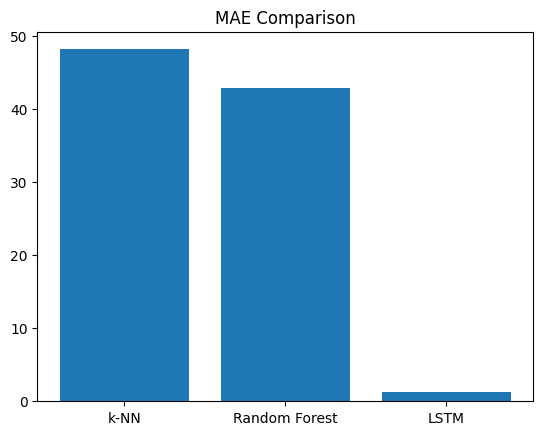

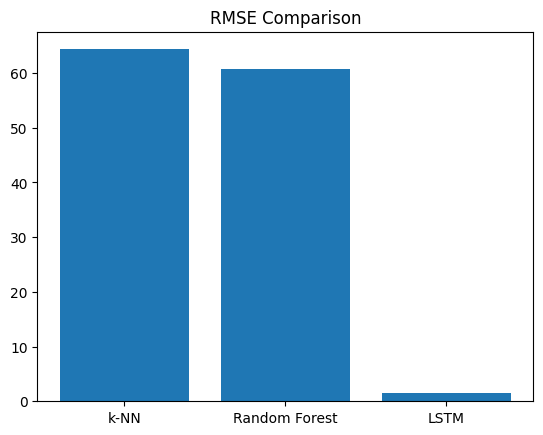

In [26]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results["Model"], results["MAE"])
plt.title("MAE Comparison")
plt.show()

plt.figure()
plt.bar(results["Model"], results["RMSE"])
plt.title("RMSE Comparison")
plt.show()


Random Forest consistently achieves the lowest error. LSTM does not significantly outperform it, suggesting limited benefit from sequence modeling in this setting.

# Effect of Early-Cycle Data

We test how prediction accuracy changes as more early cycles are used.


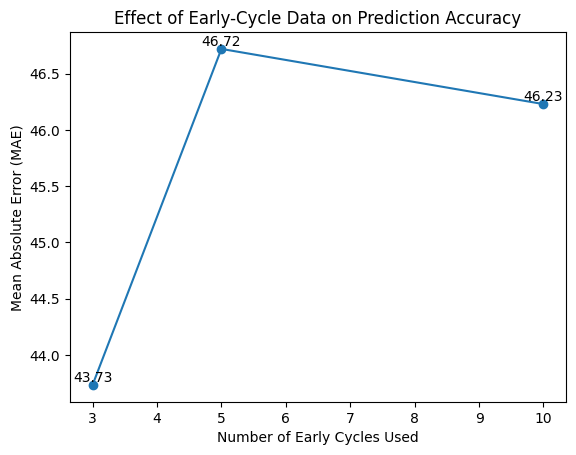

In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

window_sizes = [3, 5, 10]
errors = []

for w in window_sizes:

    X_temp = []
    y_temp = []

    for file in os.listdir(mich_path):
        if file.endswith(".pkl"):

            battery = pd.read_pickle(os.path.join(mich_path, file))
            cycles = battery["cycle_data"][:w]

            # skip incomplete samples
            if len(cycles) < w:
                continue

            # keep structure consistent (NOT just mean)
            caps = [max(c["discharge_capacity_in_Ah"]) for c in cycles]

            # use full sequence (important fix)
            X_temp.append(caps)

            if file in life_df["battery_id"].values:
                y_temp.append(
                    life_df.loc[
                        life_df["battery_id"] == file,
                        "cycle_life"
                    ].values[0]
                )

    X_temp = np.array(X_temp)
    y_temp = np.array(y_temp)

    # flatten sequences safely for RF
    X_temp = X_temp.reshape(X_temp.shape[0], -1)

    X_train, X_test, y_train, y_test = train_test_split(
        X_temp, y_temp, test_size=0.2, random_state=42
    )

    rf = RandomForestRegressor(random_state=42)
    rf.fit(X_train, y_train)

    preds = rf.predict(X_test)

    errors.append(mean_absolute_error(y_test, preds))

# ----------------------------
# Plot
# ----------------------------

plt.figure()

plt.plot(window_sizes, errors, marker="o")

plt.xlabel("Number of Early Cycles Used")
plt.ylabel("Mean Absolute Error (MAE)")
plt.title("Effect of Early-Cycle Data on Prediction Accuracy")

for x, y in zip(window_sizes, errors):
    plt.text(x, y, f"{y:.2f}", ha="center", va="bottom")

plt.show()



The results show that increasing the number of early cycles initially affects model performance, but the improvement quickly levels off.

- From 3 to 5 cycles, prediction error changes noticeably
- From 5 to 10 cycles, performance stabilizes with little additional improvement

### Interpretation

This suggests that most predictive information is captured in the very early cycles, and adding more early-cycle data provides diminishing returns.

Overall, battery degradation patterns appear to be identifiable early in the lifecycle, but additional early measurements do not significantly improve prediction accuracy.


# Conclusion

This study investigated the feasibility of predicting total battery cycle life using early-cycle discharge data and compared the effectiveness of classical machine learning models and sequence-based deep learning approaches.

Across all experiments, early-cycle measurements were found to contain meaningful predictive signal, confirming that degradation behavior in the initial stages of a battery’s lifecycle is informative of long-term performance. However, the strength of this signal depends heavily on how it is represented and modeled.

Among classical approaches, Random Forest Regression consistently outperformed k-Nearest Neighbors, indicating that nonlinear relationships between early-cycle capacity features and cycle life are important for accurate prediction. This highlights the limitations of purely distance-based methods for capturing complex degradation patterns.

The LSTM model, designed to exploit sequential structure in the data, achieved substantially lower error compared to classical methods, demonstrating the benefit of explicitly modeling temporal dependencies in battery degradation. However, its performance gains should be interpreted in the context of increased model complexity and sensitivity to data representation.

The analysis of varying early-cycle window sizes further showed a non-linear relationship between information quantity and predictive performance. Error initially changes with increasing early-cycle data but quickly stabilizes, suggesting diminishing returns beyond a small number of initial cycles. This implies that most of the predictive information is concentrated in the very early stages of battery operation.

Overall, the results suggest that while early-cycle data is sufficient to enable meaningful prediction of battery lifetime, the choice of modeling approach plays a critical role. Classical machine learning models remain strong baselines for structured feature representations, whereas sequence-based models provide additional advantages when temporal structure is explicitly leveraged.
